In [1]:
# Explainable machine learning for household electricity demand forecasting.
#
# Dataset  : UCI Individual Household Electric Power Consumption
#            (December 2006 to November 2010, one-minute resolution)
# Target   : Global_active_power (kW)
# Pipeline : XGBoost, LightGBM, CatBoost and Random Forest base learners
#            combined by a constrained convex blend. The Holt-Winters
#            decomposition is retained as an analysis layer only.


In [2]:
# Package installation

import subprocess, sys

_PACKAGES = [
    'pandas>=1.5', 'numpy>=1.23', 'matplotlib>=3.6',
    'seaborn>=0.12', 'scikit-learn>=1.3', 'statsmodels>=0.14',
    'shap>=0.42', 'lime>=0.2', 'scipy>=1.10',
    'xgboost>=1.7', 'lightgbm>=4.0', 'catboost>=1.2', 'joblib>=1.2',
    'arch>=5.3',  # circular block bootstrap for autocorrelated residuals
]
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', '-q'] + _PACKAGES
)
print('Package installation complete.')


Package installation complete.


In [3]:
# Imports and global configuration

from __future__ import annotations
import gc, warnings, json, time
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, wilcoxon

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from xgboost import XGBRegressor
import lightgbm
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
import shap
from lime.lime_tabular import LimeTabularExplainer
import joblib


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directory
OUTPUT_DIR = Path('results')
OUTPUT_DIR.mkdir(exist_ok=True)

# Plot style
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi':      110,
    'figure.figsize':  (12, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size':       10,
})
PALETTE = {
    'primary':   '#1f4e8c',
    'secondary': '#c0392b',
    'accent':    '#27ae60',
    'neutral':   '#7f8c8d',
}

# Figure conventions
plt.rcParams.update({
    'font.size':       11,
    'axes.titlesize':  12,
    'axes.labelsize':  11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'savefig.dpi':     400,
    'pdf.fonttype':    42, 
    'ps.fonttype':     42,
})

def savefig_pub(stem, fig=None, **kwargs):
    """Save a figure as a 400-dpi raster and a vector copy."""
    fig = fig if fig is not None else plt.gcf()
    kwargs.setdefault('bbox_inches', 'tight')
    fig.savefig(OUTPUT_DIR / f'{stem}.png', dpi=300, **kwargs)
    fig.savefig(OUTPUT_DIR / f'{stem}.pdf', **kwargs)

# Descriptive feature labels.


_RAW_VAR_LABELS = {
    'Global_active_power':   'Active power (kW)',
    'Global_reactive_power': 'Reactive power (kVAr)',
    'Voltage':               'Voltage (V)',
    'Global_intensity':      'Current intensity (A)',
    'Sub_metering_1':        'Kitchen sub-meter (Wh)',
    'Sub_metering_2':        'Laundry sub-meter (Wh)',
    'Sub_metering_3':        'Water-heater sub-meter (Wh)',
}

def _dur_label(m):
    """Readable duration for a horizon of m minutes."""
    m = int(m)
    if m % 1440 == 0:
        d = m // 1440
        return '1 day' if d == 1 else f'{d} days'
    if m % 60 == 0:
        h = m // 60
        return '1 hour' if h == 1 else f'{h} hours'
    return '1 minute' if m == 1 else f'{m} minutes'

def pub_label(feat):
    """Descriptive label for an engineered-feature name."""
    import re as _re
    f = str(feat)
    _fixed = {
        'diff_lag1_lag2':        'Load change (1 minute)',
        'diff_lag1_lag60':       'Load change (1 hour)',
        'gap_vs_yesterday':      'Change from previous day',
        'gap_vs_last_week':      'Change from previous week',
        'gap_vs_daily_mean':     'Deviation from daily mean',
        'gap_vs_weekly_mean':    'Deviation from weekly mean',
        'interaction_hour_lag1': 'Recent load by hour of day',
        'hour_sin':   'Hour of day (sine)',
        'hour_cos':   'Hour of day (cosine)',
        'day_sin':    'Day of week (sine)',
        'day_cos':    'Day of week (cosine)',
        'month_sin':  'Month of year (sine)',
        'month_cos':  'Month of year (cosine)',
        'mon_sin':    'Month of year (sine)',
        'mon_cos':    'Month of year (cosine)',
        'is_weekend': 'Weekend indicator',
        'hw_trend':        'Holt-Winters trend',
        'hw_seasonal':     'Holt-Winters seasonal term',
        'hw_residual':     'Holt-Winters residual',
        'hw_log_forecast': 'Holt-Winters forecast',
    }
    if f in _fixed:
        return _fixed[f]
    if f in _RAW_VAR_LABELS:
        return _RAW_VAR_LABELS[f]
    if f.endswith('_was_missing'):
        base = f[:-len('_was_missing')]
        base_lbl = _RAW_VAR_LABELS.get(base, base.replace('_', ' '))
        return f'Imputed reading ({base_lbl.split(" (")[0].lower()})'
    m = _re.search(r'_lag_(\d+)$', f)
    if m:
        return f'Load {_dur_label(int(m.group(1)))} earlier'
    m = _re.search(r'_roll_(mean|std|min|max)_(\d+)$', f)
    if m:
        stat = {'mean': 'Mean load', 'std': 'Standard deviation',
                'min': 'Minimum load', 'max': 'Maximum load'}[m.group(1)]
        return f'{stat} ({_dur_label(int(m.group(2)))})'
    m = _re.search(r'_ewm_(\d+)$', f)
    if m:
        return f'Smoothed load ({_dur_label(int(m.group(1)))})'
    m = _re.search(r'^f(?:ourier_)?([dw])_(sin|cos)_(\d+)$', f)
    if m:
        scope = 'Daily' if m.group(1) == 'd' else 'Weekly'
        trig = 'sine' if m.group(2) == 'sin' else 'cosine'
        return f'{scope} harmonic {m.group(3)} ({trig})'
    m = _re.search(r'hw_res(?:idual)?_lag_?(\d+)$', f)
    if m:
        return f'Holt-Winters residual ({_dur_label(int(m.group(1)))} earlier)'
    return f.replace('_', ' ')

print(f"Environment configured. Random seed: {RANDOM_STATE}")


Environment configured. Random seed: 42


In [4]:
# Data acquisition


import urllib.request, zipfile

DATA_URL  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip'
DATA_ZIP  = Path('household_power_consumption.zip')
DATA_FILE = Path('household_power_consumption.txt')

if not DATA_FILE.exists():
    print('Downloading dataset...')
    urllib.request.urlretrieve(DATA_URL, DATA_ZIP)
    with zipfile.ZipFile(DATA_ZIP, 'r') as z:
        z.extractall('.')
    print('Download complete.')
else:
    print('Dataset already present on disk.')


Dataset already present on disk.


In [5]:
# Parsing and initial data-quality assessment
# The character '?' denotes a missing reading. The Date and Time fields are
# combined into a regular one-minute DatetimeIndex.

df_raw = pd.read_csv(
    DATA_FILE, sep=';', na_values=['?'],
    low_memory=False, dtype=str
)
dt = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'],
    format='%d/%m/%Y %H:%M:%S', errors='coerce'
)
df_raw = df_raw.drop(columns=['Date', 'Time'])
df_raw.index = dt
df_raw = df_raw[~df_raw.index.isna()].sort_index()
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]
df_raw = df_raw.asfreq('1min')  # inserting empty rows for any skipped minutes

NUMERIC_COLS = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
for col in NUMERIC_COLS:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f"Shape          : {df_raw.shape}")
print(f"Date range     : {df_raw.index.min()} to {df_raw.index.max()}")
print(f"Missing values : {df_raw[NUMERIC_COLS].isna().sum().sum():,}")

summary = df_raw[NUMERIC_COLS].describe().T
summary['missing_pct'] = df_raw[NUMERIC_COLS].isna().mean() * 100
print("\n--- Descriptive statistics ---")
print(summary.round(4).to_string())


Shape          : (2075259, 7)
Date range     : 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Missing values : 181,853

--- Descriptive statistics ---
                           count      mean     std      min      25%      50%      75%      max  missing_pct
Global_active_power    2049280.0    1.0916  1.0573    0.076    0.308    0.602    1.528   11.122       1.2518
Global_reactive_power  2049280.0    0.1237  0.1127    0.000    0.048    0.100    0.194    1.390       1.2518
Voltage                2049280.0  240.8399  3.2400  223.200  238.990  241.010  242.890  254.150       1.2518
Global_intensity       2049280.0    4.6278  4.4444    0.200    1.400    2.600    6.400   48.400       1.2518
Sub_metering_1         2049280.0    1.1219  6.1530    0.000    0.000    0.000    0.000   88.000       1.2518
Sub_metering_2         2049280.0    1.2985  5.8220    0.000    0.000    0.000    1.000   80.000       1.2518
Sub_metering_3         2049280.0    6.4584  8.4372    0.000    0.000    1.000   17.000   3

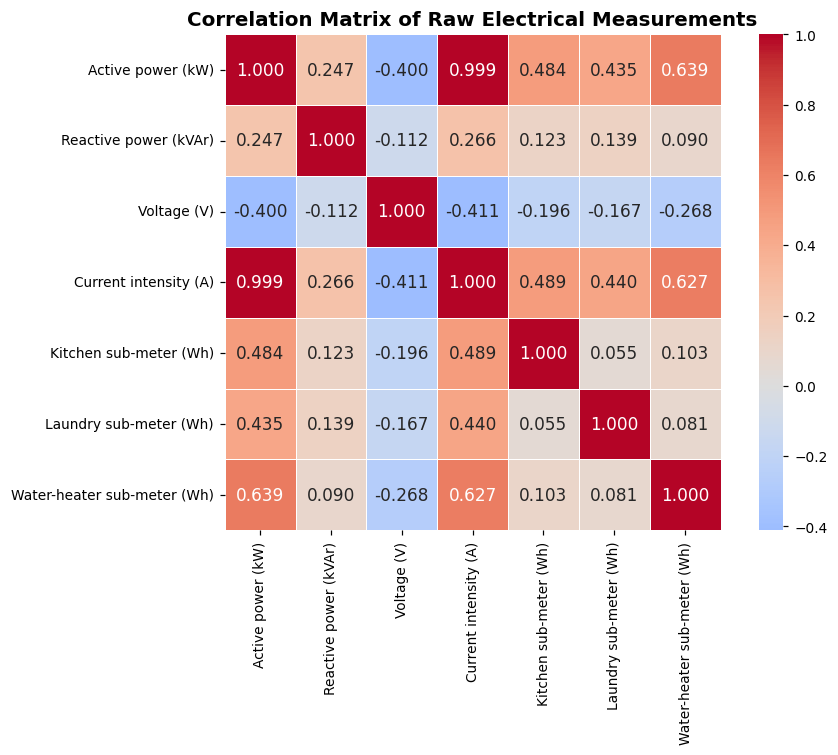

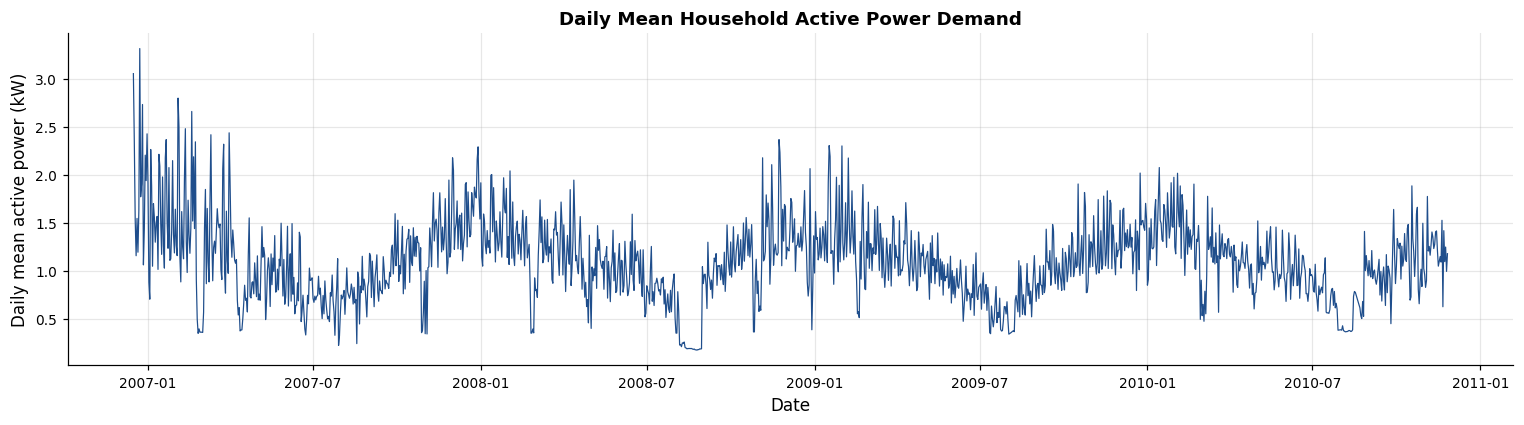


Running ADF on 34,168 hourly observations ...
ADF Statistic : -14.2374
p-value       : 1.5588e-26
  Critical (1%): -3.4305
  Critical (5%): -2.8616
  Critical (10%): -2.5668
Decision      : STATIONARY


1810

In [6]:
# Exploratory data analysis

# (a) Correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))
corr  = df_raw[NUMERIC_COLS].corr()
# Descriptive measurement 
short = ['Active power (kW)', 'Reactive power (kVAr)', 'Voltage (V)',
         'Current intensity (A)', 'Kitchen sub-meter (Wh)',
         'Laundry sub-meter (Wh)', 'Water-heater sub-meter (Wh)']
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    xticklabels=short, yticklabels=short, ax=ax
)
ax.set_title('Correlation Matrix of Raw Electrical Measurements',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig_pub('eda_correlation_heatmap')
plt.show()

# (b) Daily mean demand series
daily = df_raw['Global_active_power'].resample('D').mean().dropna()
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, linewidth=0.8, color=PALETTE['primary'])
ax.set_title('Daily Mean Household Active Power Demand', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Daily mean active power (kW)'); ax.grid(alpha=0.3)
plt.tight_layout()
savefig_pub('eda_daily_power')
plt.show()

# (c) Augmented Dickey-Fuller stationarity test on hourly aggregates
series_hourly = df_raw['Global_active_power'].resample('h').mean().dropna()
print(f"\nRunning ADF on {len(series_hourly):,} hourly observations ...")
adf_stat, p_val, used_lag, nobs, crit_vals, _ = adfuller(series_hourly)
print(f"ADF Statistic : {adf_stat:.4f}")
print(f"p-value       : {p_val:.4e}")
for k, v in crit_vals.items():
    print(f"  Critical ({k}): {v:.4f}")
decision = 'STATIONARY' if p_val < 0.05 else 'NON-STATIONARY'
print(f"Decision      : {decision}")
del series_hourly; gc.collect()


In [7]:
# Preprocessing


df = df_raw[NUMERIC_COLS].copy()
for col in NUMERIC_COLS:
    df[f'{col}_was_missing'] = df[col].isna().astype('int8')
    df[col] = df[col].interpolate(method='time')
    df[col] = df[col].ffill().bfill()

for col in NUMERIC_COLS:
    df[col] = df[col].astype('float32')

print(f"Missing after imputation  : {df[NUMERIC_COLS].isna().sum().sum()}")
print(f"DataFrame memory          : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")


Missing after imputation  : 0
DataFrame memory          : 89.2 MB


In [8]:
# Feature engineering

df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = (df.index.dayofweek >= 5).astype('int8')

CALENDAR_FEATURES = ['hour', 'day_of_week', 'month', 'is_weekend']

for (col, period) in [('hour', 24), ('day_of_week', 7), ('month', 12)]:
    suffix = col.split('_')[0] if '_' in col else col
    df[f'{suffix}_sin'] = np.sin(2*np.pi*df[col]/period).astype('float32')
    df[f'{suffix}_cos'] = np.cos(2*np.pi*df[col]/period).astype('float32')

CYCLICAL_FEATURES = [
    'hour_sin', 'hour_cos',
    'day_sin',  'day_cos',
    'mon_sin',  'mon_cos',
    'is_weekend',
]

# Fourier seasonal basis. The ablation study determines whether these
# fourteen additional columns are retained in the model feature set.
K_DAILY  = 4  # harmonics of the 1440-minute daily cycle
K_WEEKLY = 3  # harmonics of the 10080-minute weekly cycle

minute_of_day  = (df.index.hour * 60 + df.index.minute).astype('int32')
minute_of_week = (df.index.dayofweek * 1440 + minute_of_day).astype('int32')

for k in range(1, K_DAILY + 1):
    ang = 2.0 * np.pi * k * minute_of_day / 1440.0
    df[f'fourier_d_sin_{k}'] = np.sin(ang).astype('float32')
    df[f'fourier_d_cos_{k}'] = np.cos(ang).astype('float32')

for k in range(1, K_WEEKLY + 1):
    ang = 2.0 * np.pi * k * minute_of_week / 10080.0
    df[f'fourier_w_sin_{k}'] = np.sin(ang).astype('float32')
    df[f'fourier_w_cos_{k}'] = np.cos(ang).astype('float32')

FOURIER_FEATURES = (
    [f'fourier_d_sin_{k}' for k in range(1, K_DAILY + 1)]
    + [f'fourier_d_cos_{k}' for k in range(1, K_DAILY + 1)]
    + [f'fourier_w_sin_{k}' for k in range(1, K_WEEKLY + 1)]
    + [f'fourier_w_cos_{k}' for k in range(1, K_WEEKLY + 1)]
)

del minute_of_day, minute_of_week
gc.collect()

print(f"Cyclical features  : {CYCLICAL_FEATURES}")
print(f"Fourier features   : {len(FOURIER_FEATURES)} terms "
      f"(K_daily={K_DAILY}, K_weekly={K_WEEKLY})")
print(f"Total calendar+Fourier : {len(CYCLICAL_FEATURES) + len(FOURIER_FEATURES)}")


Cyclical features  : ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'mon_sin', 'mon_cos', 'is_weekend']
Fourier features   : 14 terms (K_daily=4, K_weekly=3)
Total calendar+Fourier : 21


In [9]:
# Feature engineering: lags, rolling statistics, differences, exponentially
# weighted means and an interaction term.


TARGET          = 'Global_active_power'

LAG_STEPS       = [1, 2, 3, 5, 10, 15, 30, 60, 120, 240, 1440]

ROLLING_WINDOWS = [5, 15, 60, 180, 1440]

print(f"Generating {len(LAG_STEPS)} lag features ...")
for lag in LAG_STEPS:
    df[f'{TARGET}_lag_{lag}'] = df[TARGET].shift(lag).astype('float32')

print(f"Generating {len(ROLLING_WINDOWS)*4} rolling statistics "
      f"(mean, std. dev., minimum, maximum over {ROLLING_WINDOWS}) ...")
shifted = df[TARGET].shift(1)
for w in ROLLING_WINDOWS:
    r = shifted.rolling(window=w, min_periods=1)
    df[f'{TARGET}_roll_mean_{w}'] = r.mean().astype('float32')
    df[f'{TARGET}_roll_std_{w}']  = r.std().fillna(0).astype('float32')
    df[f'{TARGET}_roll_min_{w}']  = r.min().astype('float32')
    df[f'{TARGET}_roll_max_{w}']  = r.max().astype('float32')
del shifted

# Difference features
print("Generating difference features ...")
df['diff_lag1_lag2']  = (df[f'{TARGET}_lag_1'] - df[f'{TARGET}_lag_2']).astype('float32')
df['diff_lag1_lag60'] = (df[f'{TARGET}_lag_1'] - df[f'{TARGET}_lag_60']).astype('float32')

DIFF_FEATURES = ['diff_lag1_lag2', 'diff_lag1_lag60']

LAG_FEATURES     = [f'{TARGET}_lag_{l}' for l in LAG_STEPS]
ROLLING_FEATURES = (
    [f'{TARGET}_roll_{s}_{w}' for w in ROLLING_WINDOWS
     for s in ['mean', 'std', 'min', 'max']]
)


EWM_SPANS = [5, 30, 60, 1440]
print(f"Generating {len(EWM_SPANS)} exponentially weighted means "
      f"(spans={EWM_SPANS}) ...")
for span in EWM_SPANS:
    df[f'{TARGET}_ewm_{span}'] = (
        df[TARGET].shift(1)
        .ewm(span=span, min_periods=1, adjust=False)
        .mean()
        .astype('float32')
    )

EWM_FEATURES = [f'{TARGET}_ewm_{s}' for s in EWM_SPANS]


print("Generating hour-of-day interaction feature ...")
df['interaction_hour_lag1'] = (
    df['hour_sin'] * df[f'{TARGET}_lag_1']
).astype('float32')

INTERACTION_FEATURES = ['interaction_hour_lag1']

gc.collect()
print(f"\nAutoregressive feature counts:")
print(f"  Lags                       : {len(LAG_FEATURES)}")
print(f"  Rolling statistics         : {len(ROLLING_FEATURES)}")
print(f"  Differences                : {len(DIFF_FEATURES)}")
print(f"  Exponentially weighted     : {len(EWM_FEATURES)}")
print(f"  Interaction                : {len(INTERACTION_FEATURES)}")
print(f"  Total                      : {len(LAG_FEATURES)+len(ROLLING_FEATURES)+len(DIFF_FEATURES)+len(EWM_FEATURES)+len(INTERACTION_FEATURES)}")
print(f"  Longest lookback : {max(LAG_STEPS):,} min = {max(LAG_STEPS)/1440:.1f} days")
print(f"  Columns total    : {df.shape[1]}")
print(f"  Memory           : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")


Generating 11 lag features ...
Generating 20 rolling statistics (mean, std. dev., minimum, maximum over [5, 15, 60, 180, 1440]) ...
Generating difference features ...
Generating 4 exponentially weighted means (spans=[5, 30, 60, 1440]) ...
Generating hour-of-day interaction feature ...

Autoregressive feature counts:
  Lags                       : 11
  Rolling statistics         : 20
  Differences                : 2
  Exponentially weighted     : 4
  Interaction                : 1
  Total                      : 38
  Longest lookback : 1,440 min = 1.0 days
  Columns total    : 76
  Memory           : 738.8 MB


In [10]:
# Holt-Winters decomposition, used as an analysis layer rather than as the
# prediction base. A rolling refit with a 30-day step and an 18-month training
# window yields trend, seasonal and residual components as candidate features.


SEASONAL_PERIODS = 24
REFIT_DAYS       = 30
HISTORY_MONTHS   = 18

series_hourly     = df[TARGET].resample('h').mean().dropna()
series_hourly_log = np.log1p(series_hourly)
N_HOURLY          = len(series_hourly_log)
HW_TRAIN_END      = int(N_HOURLY * 0.70)

hw_train_series  = series_hourly_log.iloc[:HW_TRAIN_END]
hw_future_series = series_hourly_log.iloc[HW_TRAIN_END:]

print(f'HW fit on {len(hw_train_series):,} hourly obs '
      f'({hw_train_series.index.min().date()} to {hw_train_series.index.max().date()})')

hw_model_init = ExponentialSmoothing(
    hw_train_series, trend='add', seasonal='add',
    seasonal_periods=SEASONAL_PERIODS, initialization_method='estimated',
).fit(optimized=True)

hw_fitted_train_h = pd.Series(hw_model_init.fittedvalues.values, index=hw_train_series.index)
level_h  = pd.Series(hw_model_init.level.values,  index=hw_train_series.index)
season_h = pd.Series(hw_model_init.season.values, index=hw_train_series.index)

# Rolling refits for val+test
refit_starts  = pd.date_range(start=hw_future_series.index[0],
                               end=hw_future_series.index[-1], freq=f'{REFIT_DAYS}D')
forecast_chunks = []
hw_model_train  = hw_model_init

for i, refit_date in enumerate(refit_starts):
    window_end   = refit_date - pd.Timedelta(hours=1)
    window_start = window_end - pd.DateOffset(months=HISTORY_MONTHS)
    train_win = series_hourly_log.loc[
        (series_hourly_log.index >= window_start) &
        (series_hourly_log.index <= window_end)
    ]
    if len(train_win) < SEASONAL_PERIODS * 4:
        train_win = series_hourly_log.loc[series_hourly_log.index <= window_end]
    hz_end = (refit_starts[i+1] - pd.Timedelta(hours=1)
              if i+1 < len(refit_starts) else hw_future_series.index[-1])
    fc_idx = hw_future_series.index[
        (hw_future_series.index >= refit_date) & (hw_future_series.index <= hz_end)
    ]
    if len(fc_idx) == 0:
        continue
    try:
        hw_m = ExponentialSmoothing(
            train_win, trend='add', seasonal='add',
            seasonal_periods=SEASONAL_PERIODS, initialization_method='estimated',
        ).fit(optimized=True)
        fc = hw_m.forecast(steps=len(fc_idx)); fc.index = fc_idx
        forecast_chunks.append(fc)
        hw_model_train = hw_m
    except Exception as e:
        fc = hw_model_init.forecast(steps=len(fc_idx)); fc.index = fc_idx
        forecast_chunks.append(fc)

hw_log_forecast_h = (
    pd.concat([hw_fitted_train_h] + forecast_chunks)
    .pipe(lambda s: s[~s.index.duplicated(keep='first')])
    .sort_index()
    .reindex(series_hourly_log.index)
    .interpolate(method='time')
)
hw_resid_h = series_hourly_log - hw_log_forecast_h

# Forward-fill to minute level
df['hw_log_forecast'] = hw_log_forecast_h.reindex(df.index, method='ffill').bfill().astype('float32')
df['hw_residual']     = hw_resid_h.reindex(df.index,        method='ffill').bfill().astype('float32')
df['hw_trend']        = level_h.reindex(df.index,           method='ffill').bfill().astype('float32')
df['hw_seasonal']     = season_h.reindex(df.index,          method='ffill').bfill().astype('float32')

HW_FEATURES = ['hw_trend', 'hw_seasonal', 'hw_residual'] \


FITTED_HW_PARAMS = dict(
    model=hw_model_train, seasonal_periods=SEASONAL_PERIODS,
    refit_days=REFIT_DAYS, history_months=HISTORY_MONTHS,
)

_r2_hw = float(1 - np.nansum((series_hourly_log.values - hw_log_forecast_h.values)**2)
                  / np.nansum((series_hourly_log.values - series_hourly_log.mean())**2))
print(f'Rolling Holt-Winters refit complete: {len(refit_starts)} refits')
print(f'Hourly R² in log space   : {_r2_hw:.4f}   (analysis only)')
print(f'\nRole of the Holt-Winters components:')
print(f'  hw_log_forecast : excluded from the feature set')
print(f'  hw_trend        : ablation candidate')
print(f'  hw_seasonal     : ablation candidate')
print(f'  hw_residual     : ablation candidate')

del series_hourly, series_hourly_log, hw_future_series
gc.collect()


HW fit on 24,212 hourly obs (2006-12-16 to 2009-09-20)
Rolling Holt-Winters refit complete: 15 refits
Hourly R² in log space   : 0.2982   (analysis only)

Role of the Holt-Winters components:
  hw_log_forecast : excluded from the feature set
  hw_trend        : ablation candidate
  hw_seasonal     : ablation candidate
  hw_residual     : ablation candidate


0

In [11]:
# Feature engineering: memory-gap features


required = [
    f'{TARGET}_lag_1', f'{TARGET}_lag_1440',
    f'{TARGET}_roll_mean_1440',
]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing upstream features: {missing}"

l1    = df[f'{TARGET}_lag_1'].to_numpy(dtype='float32')
l1440 = df[f'{TARGET}_lag_1440'].to_numpy(dtype='float32')
rm1440 = df[f'{TARGET}_roll_mean_1440'].to_numpy(dtype='float32')

df['gap_vs_yesterday']  = (l1 - l1440 ).astype('float32')
df['gap_vs_daily_mean'] = (l1 - rm1440).astype('float32')

GAP_FEATURES = ['gap_vs_yesterday', 'gap_vs_daily_mean']

del l1, l1440, rm1440
gc.collect()

print(f"Memory-gap features : {GAP_FEATURES}")
print(f"Difference features : {['diff_lag1_lag2', 'diff_lag1_lag60']}")


Memory-gap features : ['gap_vs_yesterday', 'gap_vs_daily_mean']
Difference features : ['diff_lag1_lag2', 'diff_lag1_lag60']
